In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def create_ridgeplot_3d(data_dict, slant_factor=-0.1, vertical_spacing=7, figsize=(12, 6)):
    """
    Create a 3D-style stacked ridge plot from a dictionary of sample data.

    Parameters:
    - data_dict: dict
        Keys are sample names, values are lists or arrays of numeric values.
    - slant_factor: float
        Horizontal slant offset per vertical stack unit.
    - vertical_spacing: float
        Vertical distance between stacked samples.
    - figsize: tuple
        Figure size (width, height).

    Returns:
    - fig: matplotlib.figure.Figure
        The figure containing the ridge plot.
    """
    raw_data = pd.DataFrame(data_dict)

    # Reshape to long-form with index
    long_data = raw_data.reset_index().melt(id_vars='index', var_name='Sample', value_name='Value')
    long_data.rename(columns={'index': 'X'}, inplace=True)

    # Reverse sample order so the first key in data_dict is on top
    sample_order = list(raw_data.columns[::-1])
    sample_offsets = {sample: i * vertical_spacing for i, sample in enumerate(sample_order)}
    long_data['YOffset'] = long_data['Sample'].map(sample_offsets)

    # Apply slant direction (allow positive or negative)
    slant_factor = float(slant_factor)

    # Apply slant and stack vertically
    long_data['SlantedX'] = long_data['X'] + long_data['YOffset'] * slant_factor
    long_data['StackedValue'] = long_data['Value'] + long_data['YOffset']

    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=figsize)
    palette = sns.color_palette("cubehelix", len(sample_order))

    x_vals = np.arange(raw_data.shape[0])
    y_vals = np.array(list(sample_offsets.values()))

    # Draw perspective grid - horizontal lines
    for y in y_vals:
        ax.plot(x_vals + y * slant_factor, np.full_like(x_vals, y), color='lightgray', linestyle='--', linewidth=0.5)

    # Draw perspective grid - vertical lines
    for x in x_vals:
        x_line = x + y_vals * slant_factor
        ax.plot(x_line, y_vals, color='lightgray', linestyle='--', linewidth=0.5)

    # Plot each sample line
    for sample in sample_order:
        subset = long_data[long_data['Sample'] == sample]
        ax.plot(subset['SlantedX'], subset['StackedValue'], label=sample, color=palette[sample_order.index(sample)])

    # # Sample labels, shifted horizontally according to slant and vertical offset
    # for sample in sample_order:
    #     y_offset = sample_offsets[sample]
    #     x_label_pos = x_vals[0] + y_offset * slant_factor - 0.5  # Shift with slant
    #     ax.text(x_label_pos, y_offset + 0.5, sample, ha='right', va='center', fontsize=10, fontweight='bold')
    #
    # ax.set_yticks([])
    # ax.set_xlabel("m/z")
    # # ax.set_ylabel("Relative intensity")
    # ax.set_title("Stacked Ridge Plot of Samples with 3D Slant and Perspective Grid")
    sns.despine(ax=ax, left=True, bottom=True)
    # fig.tight_layout()

    return fig


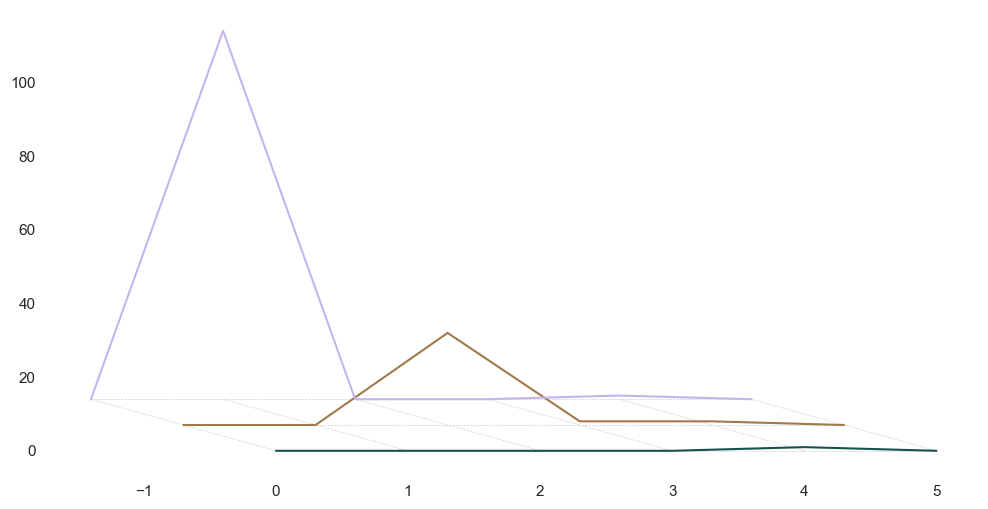

In [12]:
data = {
    'Sample1': [0,100,0,0,1,0],
    'Sample2': [0,0,25,1,1,0],
    'Sample3': [0,0,0,0,1,0],
}

fig = create_ridgeplot_3d(data, vertical_spacing=7)
plt.show()


this is how it could be implemented in the experiment object if you want to do that at some point

In [ ]:
def offset_plot(self, wells: list, xlim=None, title=None, filtered=True) -> plt.axes:
    """
    Takes a list of well IDs and returns a plot of each spectrum stacked vertically.

    X-values are determined by xlim parameter. If none provided, use the whole spectrum.
    Y-values are background corrected and always relative.
    """

    plt.style.use('default')
    fig, axis = plt.subplots(figsize=(8,6))  # width, height in inches

    for n, well in enumerate(wells):
        sample = self.samples[well]
        mz_plot = sample.mz  # initial mz
        if filtered:
            i_plot = sample.i_filtered  # initial i
        else:
            i_plot = sample.i

        if xlim:  # slice by xlim
            mz_plot, i_plot = sample.slice_spectrum(start=xlim[0], end=xlim[1], mz=mz_plot, i=i_plot)

        try:
            i_max = max(i_plot)  # scale everything relative to what is in range
            i_plot = [i * 100 / i_max for i in i_plot]
        except ZeroDivisionError:
            pass


        mz_offset = n * (xlim[1] - xlim[0]) * 0.02
        # mz_offset = 0
        # mz_plot = [mz + mz_offset for mz in mz_plot]

        i_offset = n * -120

        # i_plot = [i + i_offset for i in i_plot]

        axis.plot([mz + mz_offset for mz in mz_plot], [i + i_offset for i in i_plot], color='tab:blue', linewidth=1)
        # axis.set_ylim(0, 125)
        # axis.set_xlim(min(mz_plot), max(mz_plot))
        # axis.text(x=max(mz_plot), y=110, s=f"{sample.name} ", horizontalalignment='right')

        for moi in sample.mois:  # colour mois:
            moi_range = moi.iso_dist_range()
            mz_moi, i_moi = sample.slice_spectrum(start=moi_range[0], end=moi_range[1], mz=mz_plot, i=i_plot)
            axis.plot([mz + mz_offset for mz in mz_moi], [i + i_offset for i in i_moi], c='#d1495b', linewidth=1)
            try:
                moi_label_height = max(i_moi) + 10
            except ValueError:
                moi_label_height = 10

            # if min(mz_plot) < moi.monoisotopic_mass < max(mz_plot):  # Add species labels
                # axis.text(x=moi.monoisotopic_mass, y=moi_label_height, s=moi.name, horizontalalignment='center',
                #           fontsize=10)

    fig.text(0, 0.5, f'Relative intensity (au)', ha='left', va='center', rotation='vertical')
    plt.xlabel(f'm/z')
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)

    return fig, axis

offset_plot(run1, a_keys[:8], xlim=[4250,4950], title='dATP polymerization')